# Import libraries

In [1]:
import os
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Set random seeds

This helps make the train, validation and test splits reproducible.

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Mount Google Drive

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Set the dataset path

Change the path only when your folder is stored somewhere else.

In [4]:
data_dir = "/content/drive/MyDrive/EgyPLI"

if not os.path.exists(data_dir):
    raise FileNotFoundError(
        f"Dataset folder was not found: {data_dir}"
    )

print("Dataset path:", data_dir)

Dataset path: /content/drive/MyDrive/EgyPLI


# Configuration

224 × 224 is suitable for ConvNeXt-Tiny

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10

NUM_CLASSES = 8

# Read class folders

In [6]:
class_names = sorted([
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['Apple', 'Berry', 'Fig', 'Guava', 'Orange', 'Palm', 'Persimmon', 'Tomato']
Number of classes: 8


# Build the filepath and label DataFrame

In [7]:
filepaths = []
labels = []

valid_extensions = (".jpg", ".jpeg", ".png")

for class_name in class_names:

    class_dir = os.path.join(data_dir, class_name)

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(valid_extensions):

            filepath = os.path.join(
                class_dir,
                filename
            )

            filepaths.append(filepath)
            labels.append(class_name)

data_df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Dataset shape:", data_df.shape)

data_df.head()

Dataset shape: (3588, 2)


,filepath,label
0,/content/drive/MyDrive/EgyPLI/Apple/IMG_202407...,Apple
1,/content/drive/MyDrive/EgyPLI/Apple/IMG_202407...,Apple
2,/content/drive/MyDrive/EgyPLI/Apple/IMG_202407...,Apple
3,/content/drive/MyDrive/EgyPLI/Apple/IMG_202407...,Apple
4,/content/drive/MyDrive/EgyPLI/Apple/IMG_202407...,Apple


# Check class distribution

label
Apple        519
Berry        340
Fig          508
Guava        520
Orange       547
Palm         468
Persimmon    527
Tomato       159
Name: count, dtype: int64


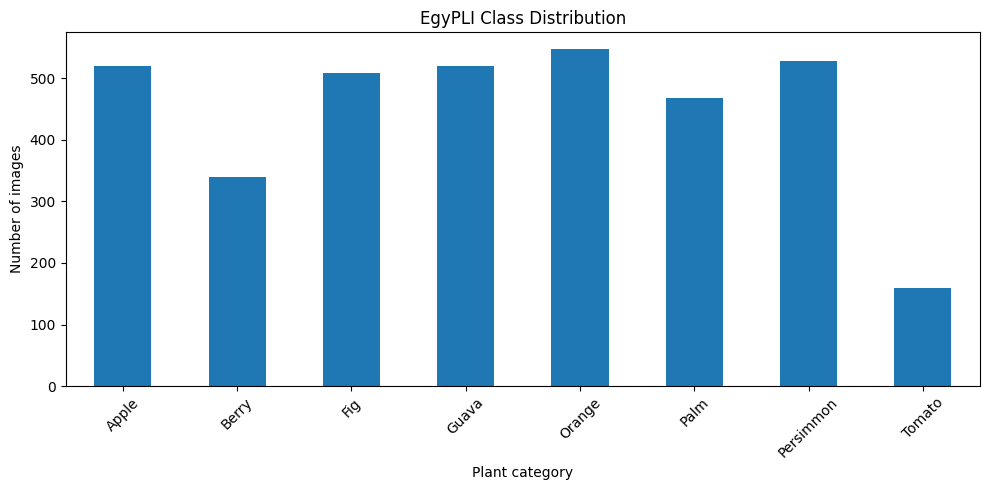

In [9]:
class_distribution = (
    data_df["label"]
    .value_counts()
    .sort_index()
)

print(class_distribution)

# isualization

plt.figure(figsize=(10, 5))

class_distribution.plot(kind="bar")

plt.title("EgyPLI Class Distribution")
plt.xlabel("Plant category")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Stratified train, validation and test split





Training: 70%
Validation: 15%
Testing: 15%


In [10]:
train_val_df, test_df = train_test_split(
    data_df,
    test_size=TEST_SPLIT,
    stratify=data_df["label"],
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=train_val_df["label"],
    random_state=SEED
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 2510
Validation images: 539
Test images: 539


Checking everry split

In [11]:
print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTesting distribution:")
print(test_df["label"].value_counts().sort_index())


Training distribution:
label
Apple        363
Berry        238
Fig          355
Guava        364
Orange       383
Palm         327
Persimmon    369
Tomato       111
Name: count, dtype: int64

Validation distribution:
label
Apple        78
Berry        51
Fig          76
Guava        78
Orange       82
Palm         71
Persimmon    79
Tomato       24
Name: count, dtype: int64

Testing distribution:
label
Apple        78
Berry        51
Fig          77
Guava        78
Orange       82
Palm         70
Persimmon    79
Tomato       24
Name: count, dtype: int64


# Reset DataFrame indices

In [12]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Create data generators

Augmentation is applied only to the training split.

In [13]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,

    fill_mode="nearest"
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create train, validation and test generators

In [14]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,

    x_col="filepath",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_dataframe(
    dataframe=val_df,

    x_col="filepath",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=False
)

test_gen = eval_datagen.flow_from_dataframe(
    dataframe=test_df,

    x_col="filepath",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=False   # shuffle=False is used for validation and test generators, predictions remain aligned with their true labels.
)

Found 2510 validated image filenames belonging to 8 classes.
Found 539 validated image filenames belonging to 8 classes.
Found 539 validated image filenames belonging to 8 classes.


# Save class mappings

In [15]:
class_indices = train_gen.class_indices

idx_to_class = {
    index: class_name
    for class_name, index in class_indices.items()
}

print("Class indices:", class_indices)
print("Index-to-class mapping:", idx_to_class)

Class indices: {'Apple': 0, 'Berry': 1, 'Fig': 2, 'Guava': 3, 'Orange': 4, 'Palm': 5, 'Persimmon': 6, 'Tomato': 7}
Index-to-class mapping: {0: 'Apple', 1: 'Berry', 2: 'Fig', 3: 'Guava', 4: 'Orange', 5: 'Palm', 6: 'Persimmon', 7: 'Tomato'}


Save the class names to Drive -

In [16]:
output_dir = "/content/drive/MyDrive/EgyPLI_ConvNeXtTiny"

os.makedirs(output_dir, exist_ok=True)

class_names_path = os.path.join(
    output_dir,
    "class_names.json"
)

with open(class_names_path, "w") as file:
    json.dump(class_indices, file, indent=4)

print("Saved class mapping to:", class_names_path)

Saved class mapping to: /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/class_names.json


# Visualize augmented images

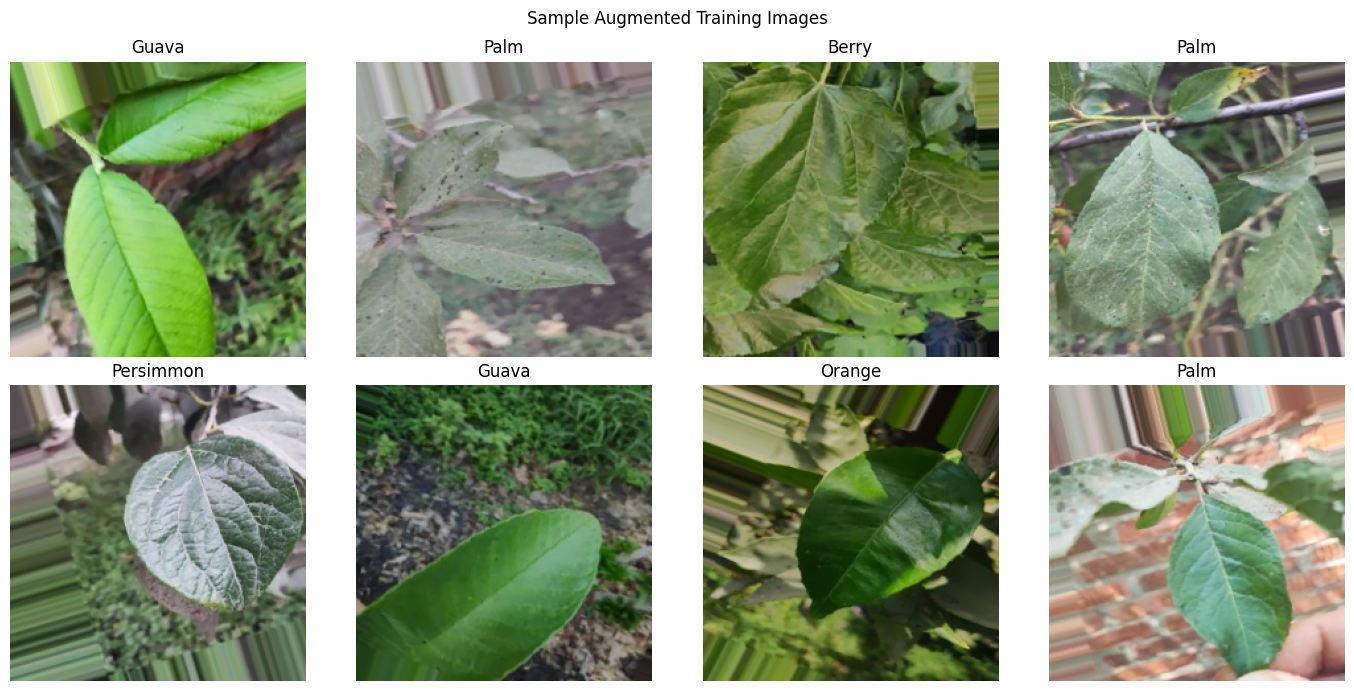

In [17]:
images, labels_batch = next(train_gen)

plt.figure(figsize=(14, 7))

for i in range(min(8, len(images))):

    plt.subplot(2, 4, i + 1)

    display_image = images[i] / 255.0

    plt.imshow(
        np.clip(
            display_image,
            0,
            1
        )
    )

    label_index = np.argmax(labels_batch[i])

    plt.title(
        idx_to_class[label_index]
    )

    plt.axis("off")

plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

Reset the generator after viewing the batch

In [18]:
train_gen.reset()

# Calculate class weights

This helps compensate for the smaller Tomato category.

In [19]:
train_labels_int = (
    train_df["label"]
    .map(class_indices)
    .values
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_int),
    y=train_labels_int
)

class_weight_dict = {
    index: weight
    for index, weight in enumerate(
        class_weights_array
    )
}

print("Class weights:")

for index, weight in class_weight_dict.items():

    print(
        f"{idx_to_class[index]:>12s}: "
        f"{weight:.3f}"
    )

Class weights:
       Apple: 0.864
       Berry: 1.318
         Fig: 0.884
       Guava: 0.862
      Orange: 0.819
        Palm: 0.959
   Persimmon: 0.850
      Tomato: 2.827


# Create the ConvNeXt-Tiny model

This is a normal transfer-learning model

In [20]:
base_model = ConvNeXtTiny(
    weights="imagenet",
    include_top=False,

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    include_preprocessing=True
)

base_model.trainable = False

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Adding a simple classification head

In [21]:
inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="input_image"
)

features = base_model(
    inputs,
    training=False
)

features = layers.GlobalAveragePooling2D()(
    features
)

features = layers.Dropout(0.30)(
    features
)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="plant_prediction"
)(
    features
)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EgyPLI_ConvNeXtTiny"
)

model.summary()

Model: "EgyPLI_ConvNeXtTiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ plant_prediction (Dense)        │ (None, 8)              │         6,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,826,280 (106.15 MB)

 Trainable params: 6,152 (24.03 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

# Compile the model

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(
            k=3,
            name="top_3_accuracy"
        )
    ]
)

# Create callbacks

In [23]:
best_model_path = os.path.join(
    output_dir,
    "best_convnext_tiny.keras"
)

callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the classification head

In [24]:
history = model.fit(
    train_gen,

    validation_data=val_gen,

    epochs=INITIAL_EPOCHS,

    class_weight=class_weight_dict,

    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.4444 - loss: 1.6370 - top_3_accuracy: 0.7028 
Epoch 1: val_accuracy improved from None to 0.95362, saving model to /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/best_convnext_tiny.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/best_convnext_tiny.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1579s 20s/step - accuracy: 0.6498 - loss: 1.2097 - top_3_accuracy: 0.8602 - val_accuracy: 0.9536 - val_loss: 0.4441 - val_top_3_accuracy: 0.9926 - learning_rate: 0.0010
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9071 - loss: 0.5508 - top_3_accuracy: 0.9873
Epoch 2: val_accuracy improved from 0.95362 to 0.96660, saving model to /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/best_convnext_tiny.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/best_convnext_tiny.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 626ms/step - accuracy: 0.9199 - loss: 0.4805 - top_3_accuracy: 0.9924

# Plot accuracy and loss

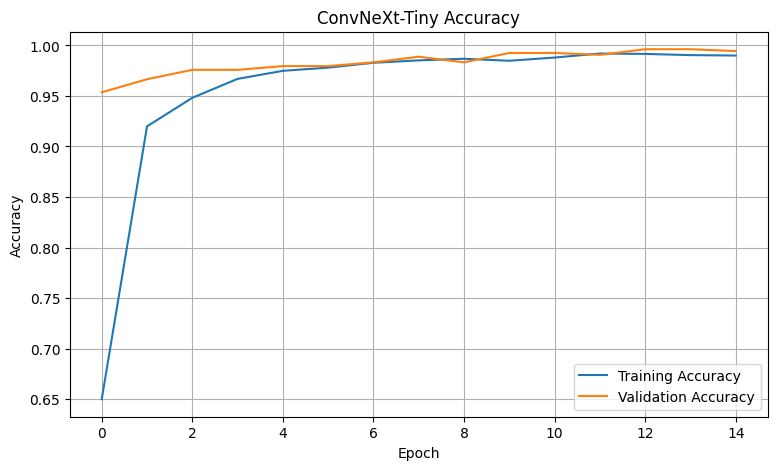

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ConvNeXt-Tiny Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

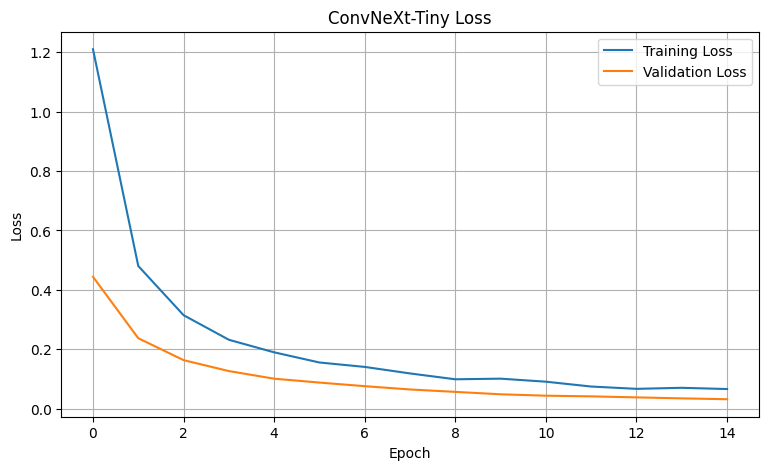

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ConvNeXt-Tiny Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# fine-tuning

In [28]:
base_model.trainable = True

In [29]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [30]:
trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable ConvNeXt layers:",
    trainable_layers
)

Trainable ConvNeXt layers: 30


Compile again with a much smaller learning rate

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

# Run fine-tuning

In [36]:
fine_tune_history = model.fit(
    train_gen,

    validation_data=val_gen,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weight_dict,

    callbacks=callbacks
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.9957 - loss: 0.0146
Epoch 1: val_accuracy did not improve from 1.00000
79/79 ━━━━━━━━━━━━━━━━━━━━ 94s 902ms/step - accuracy: 0.9972 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0046 - learning_rate: 1.0000e-05
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 1.0000 - loss: 0.0084
Epoch 2: val_accuracy did not improve from 1.00000
79/79 ━━━━━━━━━━━━━━━━━━━━ 55s 689ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0046 - learning_rate: 1.0000e-05
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9989 - loss: 0.0098
Epoch 3: val_accuracy did not improve from 1.00000
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 668ms/step - accuracy: 0.9984 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0029 - learning_rate: 1.0000e-05
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 1.0000 - loss: 0.0059
Epoch 4: val_accuracy did not improve from 1.00000
79/79 ━━━━━━━━

# Load the best model

In [37]:
best_model = tf.keras.models.load_model(
    best_model_path
)

print("Best model loaded successfully.")

Best model loaded successfully.


# Evaluate on the test set

In [38]:
test_gen.reset()

test_loss, test_accuracy, test_top3_accuracy = (
    best_model.evaluate(
        test_gen,
        verbose=1
    )
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 321ms/step - accuracy: 0.9926 - loss: 0.0307 - top_3_accuracy: 1.0000
Test loss: 0.0307
Test accuracy: 0.9926


# Generate test predictions

In [39]:
test_gen.reset()

prediction_probabilities = best_model.predict(
    test_gen,
    verbose=1
)

predicted_indices = np.argmax(
    prediction_probabilities,
    axis=1
)

true_indices = test_gen.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 411ms/step


# Classification report

In [40]:
report = classification_report(
    true_indices,
    predicted_indices,

    target_names=[
        idx_to_class[index]
        for index in range(
            len(idx_to_class)
        )
    ],

    digits=4
)

print(report)

              precision    recall  f1-score   support

       Apple     0.9873    1.0000    0.9936        78
       Berry     1.0000    0.9608    0.9800        51
         Fig     0.9747    1.0000    0.9872        77
       Guava     1.0000    1.0000    1.0000        78
      Orange     0.9880    1.0000    0.9939        82
        Palm     1.0000    0.9714    0.9855        70
   Persimmon     1.0000    1.0000    1.0000        79
      Tomato     1.0000    1.0000    1.0000        24

    accuracy                         0.9926       539
   macro avg     0.9937    0.9915    0.9925       539
weighted avg     0.9927    0.9926    0.9926       539



saving it in google drove

In [41]:
report_path = os.path.join(
    output_dir,
    "classification_report.txt"
)

with open(report_path, "w") as file:
    file.write(report)

print("Report saved to:", report_path)

Report saved to: /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/classification_report.txt


# Confusion matrix

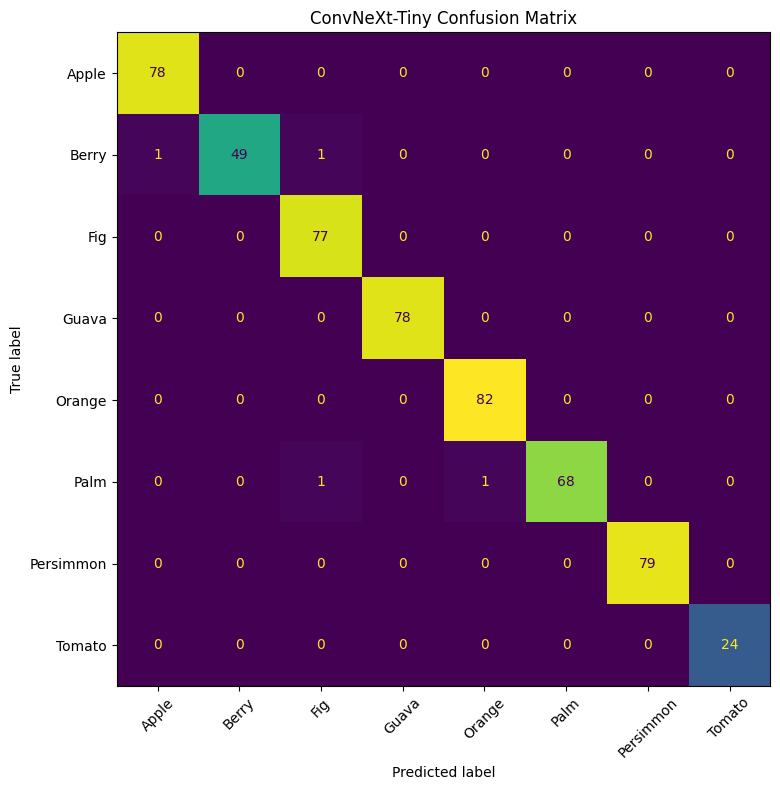

In [42]:
confusion_mat = confusion_matrix(
    true_indices,
    predicted_indices
)

display_labels = [
    idx_to_class[index]
    for index in range(
        len(idx_to_class)
    )
]

fig, ax = plt.subplots(
    figsize=(10, 8)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_mat,
    display_labels=display_labels
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title(
    "ConvNeXt-Tiny Confusion Matrix"
)

plt.tight_layout()
plt.show()

# Save the final model

In [43]:
final_model_path = os.path.join(
    output_dir,
    "convnext_tiny_egypli_final.keras"
)

best_model.save(final_model_path)

print("Final model saved to:")
print(final_model_path)

Final model saved to:
/content/drive/MyDrive/EgyPLI_ConvNeXtTiny/convnext_tiny_egypli_final.keras


# Single-image prediction function

In [44]:
from tensorflow.keras.utils import (
    load_img,
    img_to_array
)

In [45]:
def predict_plant(image_path, model):

    image = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    image_array = img_to_array(image)

    image_array = preprocess_input(
        image_array
    )

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    start_time = time.perf_counter()

    probabilities = model.predict(
        image_batch,
        verbose=0
    )[0]

    inference_time = (
        time.perf_counter() - start_time
    ) * 1000

    top_indices = np.argsort(
        probabilities
    )[::-1][:3]

    predicted_index = top_indices[0]

    predicted_class = (
        idx_to_class[predicted_index]
    )

    confidence = (
        probabilities[predicted_index]
        * 100
    )

    return {
        "image": image,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "inference_time_ms": inference_time,
        "top_indices": top_indices,
        "probabilities": probabilities
    }

# Display one prediction

In [47]:
def display_prediction(
    image_path,
    model
):

    result = predict_plant(
        image_path,
        model
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(result["image"])
    plt.axis("off")

    plt.title(
        f'{result["predicted_class"]}\n'
        f'Confidence: '
        f'{result["confidence"]:.2f}%'
    )

    plt.show()

    print(
        "Predicted class:",
        result["predicted_class"]
    )

    print(
        "Confidence:",
        f'{result["confidence"]:.2f}%'
    )

    print(
        "Inference time:",
        f'{result["inference_time_ms"]:.2f} ms'
    )

    print("\nTop 3 predictions:")

    for rank, class_index in enumerate(
        result["top_indices"],
        start=1
    ):

        class_name = (
            idx_to_class[class_index]
        )

        probability = (
            result["probabilities"][
                class_index
            ] * 100
        )

        print(
            f"{rank}. "
            f"{class_name}: "
            f"{probability:.2f}%"
        )

Test it using an image from Drive

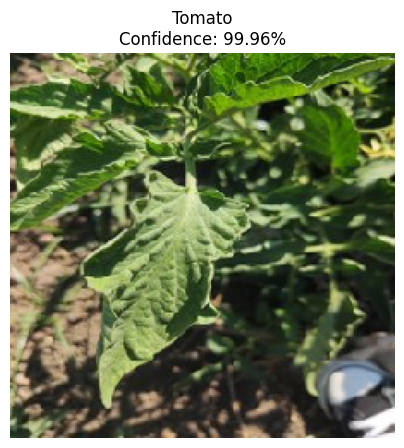

Predicted class: Tomato
Confidence: 99.96%
Inference time: 10347.99 ms

Top 3 predictions:
1. Tomato: 99.96%
2. Guava: 0.02%
3. Apple: 0.01%


In [48]:
sample_image = test_df.iloc[0]["filepath"]

display_prediction(
    sample_image,
    best_model
)

# Five-image evaluator demonstration

In [54]:
from google.colab import files

uploaded_images = files.upload()

Saving IMG_20240710_170121_1.jpg to IMG_20240710_170121_1.jpg
Saving IMG_20240710_170123_2.jpg to IMG_20240710_170123_2.jpg
Saving IMG_20240710_170127.jpg to IMG_20240710_170127.jpg
Saving IMG_20240710_170230_2.jpg to IMG_20240710_170230_2.jpg
Saving IMG_20240710_170232_1.jpg to IMG_20240710_170232_1.jpg


Check exactly five images

In [55]:
demo_image_paths = []

for filename in uploaded_images.keys():

    if filename.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        demo_image_paths.append(
            f"/content/{filename}"
        )

if len(demo_image_paths) != 5:

    raise ValueError(
        "Please upload exactly five images. "
        f"You uploaded {len(demo_image_paths)}."
    )

print("Five evaluator images received.")

Five evaluator images received.


# Predict all five image

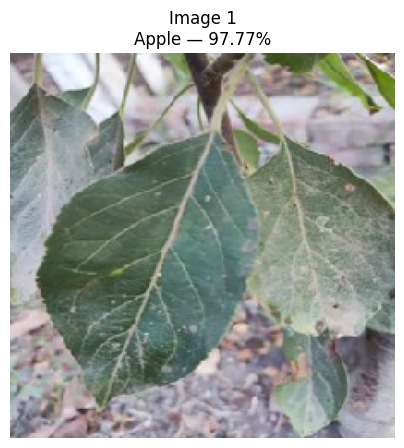

Image 1: IMG_20240710_170121_1.jpg
Predicted plant: Apple
Confidence: 97.77%
Inference time: 87.85 ms
Top 3 predictions:
1. Apple: 97.77%
2. Fig: 1.44%
3. Palm: 0.77%


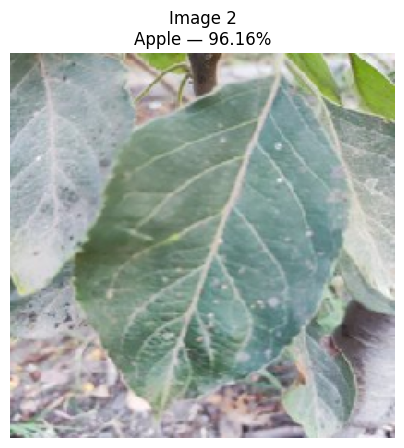

Image 2: IMG_20240710_170123_2.jpg
Predicted plant: Apple
Confidence: 96.16%
Inference time: 94.57 ms
Top 3 predictions:
1. Apple: 96.16%
2. Fig: 3.49%
3. Palm: 0.22%


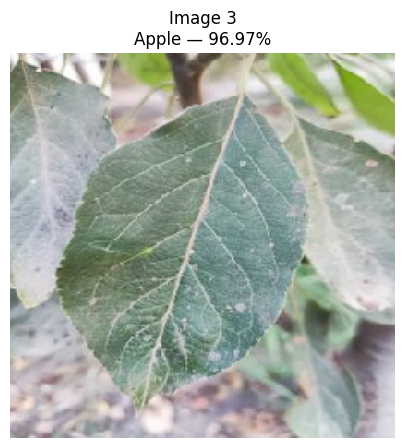

Image 3: IMG_20240710_170127.jpg
Predicted plant: Apple
Confidence: 96.97%
Inference time: 135.13 ms
Top 3 predictions:
1. Apple: 96.97%
2. Palm: 2.84%
3. Fig: 0.15%


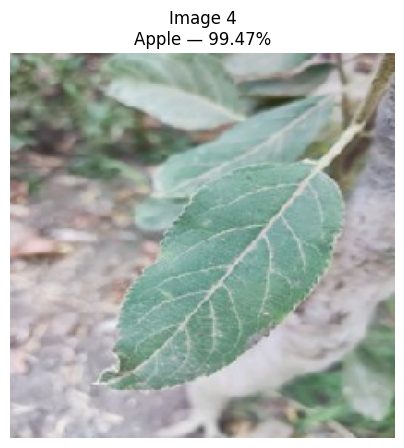

Image 4: IMG_20240710_170230_2.jpg
Predicted plant: Apple
Confidence: 99.47%
Inference time: 118.27 ms
Top 3 predictions:
1. Apple: 99.47%
2. Palm: 0.50%
3. Berry: 0.02%


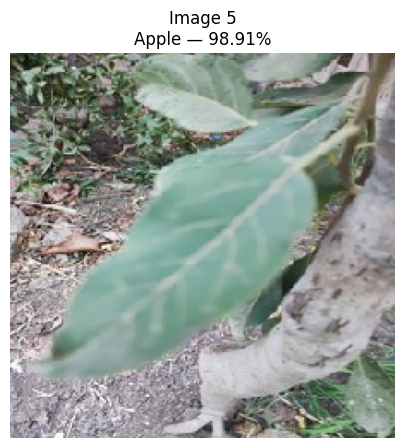

Image 5: IMG_20240710_170232_1.jpg
Predicted plant: Apple
Confidence: 98.91%
Inference time: 150.47 ms
Top 3 predictions:
1. Apple: 98.91%
2. Fig: 0.81%
3. Palm: 0.17%


In [56]:
demo_results = []

for image_number, image_path in enumerate(
    demo_image_paths,
    start=1
):

    result = predict_plant(
        image_path,
        best_model
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(result["image"])
    plt.axis("off")

    plt.title(
        f"Image {image_number}\n"
        f"{result['predicted_class']} — "
        f"{result['confidence']:.2f}%"
    )

    plt.show()

    print("=" * 50)

    print(
        f"Image {image_number}:",
        os.path.basename(image_path)
    )

    print(
        "Predicted plant:",
        result["predicted_class"]
    )

    print(
        "Confidence:",
        f"{result['confidence']:.2f}%"
    )

    print(
        "Inference time:",
        f"{result['inference_time_ms']:.2f} ms"
    )

    print("Top 3 predictions:")

    top_prediction_data = {}

    for rank, class_index in enumerate(
        result["top_indices"],
        start=1
    ):

        class_name = (
            idx_to_class[class_index]
        )

        probability = (
            result["probabilities"][
                class_index
            ] * 100
        )

        print(
            f"{rank}. "
            f"{class_name}: "
            f"{probability:.2f}%"
        )

        top_prediction_data[
            f"top_{rank}_class"
        ] = class_name

        top_prediction_data[
            f"top_{rank}_confidence"
        ] = probability

    demo_row = {
        "image_number": image_number,
        "filename": os.path.basename(
            image_path
        ),
        "predicted_class": result[
            "predicted_class"
        ],
        "confidence": result[
            "confidence"
        ],
        "inference_time_ms": result[
            "inference_time_ms"
        ]
    }

    demo_row.update(
        top_prediction_data
    )

    demo_results.append(
        demo_row
    )

    print("=" * 50)

# Show five-image result table

In [60]:
import pandas as pd
from IPython.display import display

Check whether demo_results exists

In [61]:
print(type(demo_results))
print("Number of results:", len(demo_results))

<class 'list'>
Number of results: 5


In [62]:
demo_results_df = pd.DataFrame(
    demo_results
)

display(demo_results_df)

,image_number,filename,predicted_class,confidence,inference_time_ms,top_1_class,top_1_confidence,top_2_class,top_2_confidence,top_3_class,top_3_confidence
0,1,IMG_20240710_170121_1.jpg,Apple,97.769424,87.854372,Apple,97.769424,Fig,1.441942,Palm,0.769862
1,2,IMG_20240710_170123_2.jpg,Apple,96.163269,94.567471,Apple,96.163269,Fig,3.490692,Palm,0.222170
2,3,IMG_20240710_170127.jpg,Apple,96.974388,135.126937,Apple,96.974388,Palm,2.844481,Fig,0.148139
3,4,IMG_20240710_170230_2.jpg,Apple,99.473625,118.272999,Apple,99.473625,Palm,0.499872,Berry,0.016326
4,5,IMG_20240710_170232_1.jpg,Apple,98.907593,150.468309,Apple,98.907593,Fig,0.810542,Palm,0.170229


# Simpler result table

For a less complex table, use only the main prediction:

In [63]:
simple_results = []

for image_number, image_path in enumerate(
    demo_image_paths,
    start=1
):
    result = predict_plant(
        image_path,
        best_model
    )

    simple_results.append({
        "Image": image_number,
        "Filename": os.path.basename(image_path),
        "Predicted Class": result["predicted_class"],
        "Confidence (%)": round(
            float(result["confidence"]),
            2
        ),
        "Inference Time (ms)": round(
            float(result["inference_time_ms"]),
            2
        )
    })

demo_results_df = pd.DataFrame(simple_results)

display(demo_results_df)

,Image,Filename,Predicted Class,Confidence (%),Inference Time (ms)
0,1,IMG_20240710_170121_1.jpg,Apple,97.77,268.04
1,2,IMG_20240710_170123_2.jpg,Apple,96.16,194.99
2,3,IMG_20240710_170127.jpg,Apple,96.97,197.95
3,4,IMG_20240710_170230_2.jpg,Apple,99.47,218.11
4,5,IMG_20240710_170232_1.jpg,Apple,98.91,255.08


Save it to Drive

In [64]:
demo_results_path = os.path.join(
    output_dir,
    "five_image_demo_results.csv"
)

demo_results_df.to_csv(
    demo_results_path,
    index=False
)

print(
    "Demo results saved to:",
    demo_results_path
)

Demo results saved to: /content/drive/MyDrive/EgyPLI_ConvNeXtTiny/five_image_demo_results.csv


# Calculate accuracy for the five demo images

In [69]:
from IPython.display import display

print("Available columns:", demo_results_df.columns.tolist())

if len(true_demo_labels) != 5:
    raise ValueError("Enter exactly five true labels.")

if len(demo_results_df) != 5:
    raise ValueError(
        f"The result table contains {len(demo_results_df)} rows, not 5."
    )

# Select the prediction column that exists
if "predicted_class" in demo_results_df.columns:
    prediction_column = "predicted_class"

elif "Predicted Class" in demo_results_df.columns:
    prediction_column = "Predicted Class"

else:
    raise KeyError(
        "Prediction column was not found. "
        f"Available columns are: {demo_results_df.columns.tolist()}"
    )

demo_results_df["true_class"] = true_demo_labels

demo_results_df["correct"] = (
    demo_results_df[prediction_column]
    .astype(str)
    .str.strip()
    .str.lower()
    ==
    demo_results_df["true_class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

demo_accuracy = demo_results_df["correct"].mean()

print(
    "Five-image demo accuracy:",
    f"{demo_accuracy * 100:.2f}%"
)

display(demo_results_df)

Available columns: ['Image', 'Filename', 'Predicted Class', 'Confidence (%)', 'Inference Time (ms)', 'true_class']
Five-image demo accuracy: 20.00%


,Image,Filename,Predicted Class,Confidence (%),Inference Time (ms),true_class,correct
0,1,IMG_20240710_170121_1.jpg,Apple,97.77,268.04,Apple,True
1,2,IMG_20240710_170123_2.jpg,Apple,96.16,194.99,Guava,False
2,3,IMG_20240710_170127.jpg,Apple,96.97,197.95,Palm,False
3,4,IMG_20240710_170230_2.jpg,Apple,99.47,218.11,Orange,False
4,5,IMG_20240710_170232_1.jpg,Apple,98.91,255.08,Tomato,False


In [70]:
true_demo_labels = [
    "Apple",
    "Guava",
    "Palm",
    "Orange",
    "Tomato"
]

In [71]:
demo_results_df = demo_results_df.rename(
    columns={
        "Predicted Class": "predicted_class",
        "Confidence (%)": "confidence",
        "Filename": "filename",
        "Image": "image_number"
    }
)

print(demo_results_df.columns.tolist())

['image_number', 'filename', 'predicted_class', 'confidence', 'Inference Time (ms)', 'true_class', 'correct']


In [72]:
if len(true_demo_labels) != 5:
    raise ValueError("Enter exactly five true labels.")

demo_results_df["true_class"] = true_demo_labels

demo_results_df["correct"] = (
    demo_results_df["predicted_class"]
    .astype(str)
    .str.strip()
    .str.lower()
    ==
    demo_results_df["true_class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

demo_accuracy = demo_results_df["correct"].mean()

print(
    "Five-image demo accuracy:",
    f"{demo_accuracy * 100:.2f}%"
)

display(demo_results_df)

Five-image demo accuracy: 20.00%


,image_number,filename,predicted_class,confidence,Inference Time (ms),true_class,correct
0,1,IMG_20240710_170121_1.jpg,Apple,97.77,268.04,Apple,True
1,2,IMG_20240710_170123_2.jpg,Apple,96.16,194.99,Guava,False
2,3,IMG_20240710_170127.jpg,Apple,96.97,197.95,Palm,False
3,4,IMG_20240710_170230_2.jpg,Apple,99.47,218.11,Orange,False
4,5,IMG_20240710_170232_1.jpg,Apple,98.91,255.08,Tomato,False
